I used Gemini with the guided learning enabled to help me with understanding, and walking me through the steps to solve everything while asking questions of me and I of it.


In [9]:
from scipy import stats
import numpy as np

In [10]:
#1

#1.1
#N = 100, k=23,
#p_hat = k/N = 23/100 = MLE

#1.2
samples = stats.bernoulli.rvs(0.23, size=100)
var_hat = 0.23*(1-0.23)/100
std_err = np.sqrt(var_hat)
var_hat, std_err

(0.001771, np.float64(0.042083250825001625))

In [12]:
confidence_interval_95 = (0.23 - 1.96*std_err, 0.23 + 1.96*std_err)
confidence_interval_95

(np.float64(0.14751682838299685), np.float64(0.3124831716170032))

In [23]:
#1.3
heads = np.ones(23)
tails = np.zeros(77)

N=100
head23_tail77 = np.concatenate((tails, heads))

bootstrap_means = [np.mean(np.random.choice(head23_tail77, size=N, replace=True)) for _ in range(0, 10000)]

bootstrap_means[:3]

[np.float64(0.24), np.float64(0.26), np.float64(0.19)]

In [26]:
#percentile
confidence_interval_95_percentile = np.percentile(bootstrap_means, [2.5, 97.5])
confidence_interval_95_percentile

array([0.15, 0.32])

In [28]:
#pivotal
p_hat = 0.23
confidence_interval_95_pivotal = (2*p_hat - confidence_interval_95_percentile[1], 2*p_hat - confidence_interval_95_percentile[0])
confidence_interval_95_pivotal

(np.float64(0.14), np.float64(0.31000000000000005))

Personal notes:
MLE
$$\hat{p} = \frac{k}{N} = \frac{23}{100} = 0.23$$

Using central limit theorem
$$\hat{p} \sim \mathcal{N}\left(p, \, \frac{1}{I(p)}\right)$$

 $I(p)$ is the Fisher Information for $N$ observations.

 For $N$ Bernoulli trials, the Fisher Information is given by:$$I(p) = \frac{N}{p(1-p)}$$

 $$\widehat{\text{Var}}(\hat{p}) = \frac{1}{I(\hat{p})} = \frac{\hat{p}(1-\hat{p})}{N}$$


 $$\text{CI} = \hat{p} \pm z_{0.975} \times \text{SE}$$

 $\text{For CI 95\%}: z_{0.975} \approx 1.96$.

# Ex2

2.1
Likelihood fun is $L(a,b)$ => joint PDF

$X \sim \text{Uniform}(a, b)$, its PDF is:$$f(x; a, b) = \begin{cases} \frac{1}{b - a} & \text{if } a \le x \le b \\ 0 & \text{otherwise} \end{cases}$$

personal note: To maximize $L(a,b)$, need to make denominator really small. To minimize the length of the interval $(b-a)$, we need to have values of $a$ and $b$ to be really close to one another, but not $0$. $a$ can be as large as $x$, but no larger, and $b$ can be as small as $x$, but no smaller.

$$\hat{a} = \min(X_1, X_2, X_3, X_4) = X_{(1)}$$

$$\hat{b} = \max(X_1, X_2, X_3, X_4) = X_{(4)}$$

The MLEs are $\hat{a} = X_{(1)}$ and $\hat{b} = X_{(4)}$

2.2
$\int x f(x) \mathrm{d}x$ gives us the expected value or mean $\mathbb{E}[X]$

$$\tau = \int_{a}^{b} x \left(\frac{1}{b - a}\right) \mathrm{d}x = \frac{1}{b - a} \int_{a}^{b} x \mathrm{d}x$$

$$\int_{a}^{b} x \mathrm{d}x =  \frac{b^2-a^2}{2}$$
$$= \frac{(b-a)(b+a)}{2} $$
$$\tau = \frac{1}{b - a} * \frac{(b-a)(b+a)}{2} = \frac{b+a}{2} $$

$\tau = \frac{a + b}{2}$ represents the expected value $\mathbb{E}[X]$

personal note: by the invariance property of the MLE (if $\hat{\theta}$ is the MLE of $\theta$, then the MLE of a function $g(\theta)$ is simply $g(\hat{\theta})$):

$$\text MLE \hat{\tau} = \frac{\hat{b}+\hat{a}}{2}  = \frac{X_{(4)} + X_{(1)}}{2}$$

# Ex3

personal note: Method of Moments is a technique for estimating unknown parameters in a probability distribution. Equate the theoretical population moment $E[X^k]$ (the expected value based on the probability distribution) to the corresponding sample moment $\frac{1}{n} \sum_{i=1}^n X_i^k$ (calculated from observed data).

---

Theoretical moment: $E[X] = \lambda$

Sample moment: The sample mean $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$


$$\text{Theoretical Moment } E[X] = \text{Sample Moment } \bar{X}$$

$$E[X] = \lambda = \bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i = \frac{1}{n} * n\lambda = \hat{\lambda}$$

$$\hat{\lambda} = \bar{X}$$

personal note: The Method of Moments estimator for $\lambda$ is the sample mean


# Ex4

personal note: To find the Maximum Likelihood Estimator (MLE) for $\lambda$ when $X_1, \ldots, X_n \sim \text{Poisson}(\lambda)$, we follow a standard four-step procedure: write the probability mass function, construct the likelihood function, take the natural logarithm (log-likelihood), and maximize with respect to $\lambda$.

PMF:
$$P(X_i = x_i) = \frac{e^{-\lambda} \lambda^{x_i}}{x_i!}$$

---

Likelihood fun (i.i.d):
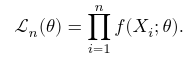

$$L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \lambda^{x_i}}{x_i!}$$

$$= L(\lambda) = \frac{e^{-n\lambda} \lambda^{\sum_{i=1}^n x_i}}{\prod_{i=1}^n x_i!}$$

---
personal note: log is good for simplifying the expression. preserves maximum (value of $\lambda$ that maximizes $\ln L(\lambda)$ is identical to the value that maximizes $L(\lambda)$. avoids arithmetic underflow.

Log likelihood fun: 

$$\ell(\lambda) = \ln L(\lambda) = \ln \left( e^{-n\lambda} \lambda^{\sum_{i=1}^n x_i} \right) - \ln \left( \prod_{i=1}^n x_i! \right)$$

 logarithmic properties $\ln(ab) = \ln(a) + \ln(b)$ and $\ln(a^b) = b \ln(a)$

 $$\ell(\lambda) = \ln \left( e^{-n\lambda} \right) + \ln \left(\lambda^{\sum_{i=1}^n x_i} \right) - \ln \left( \prod_{i=1}^n x_i! \right)$$

$$ = -n\lambda \ln \left(e\right) + \left (\sum_{i=1}^n x_i \right) \ln \left(\lambda \right) - \ln \left( \prod_{i=1}^n x_i! \right)$$

---
Maximize the Log-Likelihood Function
personal note: first derivative for finding turning point of the log likelihood curve. second derivative measures curvature of the fun to check what type of critical point it is. If $\frac{d^2\ell}{d\lambda^2} < 0$, then is concave down, maximum. If $\frac{d^2\ell}{d\lambda^2} > 0$, concave up, minimum.


notes: derivatives $\ln \left(e\right) = 0, \ln \left(\lambda \right) = \frac{1}{\lambda} $
$$\frac{d\ell}{d\lambda} = -n + \frac{\sum_{i=1}^n x_i}{\lambda}$$

derivative equal to zero to find the critical point $\hat{\lambda}$:$$-n + \frac{\sum_{i=1}^n x_i}{\hat{\lambda}} = 0$$

$$\frac{\sum_{i=1}^n x_i}{\hat{\lambda}} = n$$

$$\hat{\lambda} = \frac{1}{n} \sum_{i=1}^n x_i = \bar{X}$$

confirm this critical point is a maximum:$$\frac{d^2\ell}{d\lambda^2} = -\frac{\sum_{i=1}^n x_i}{\lambda^2}$$

---
$$\hat{\lambda}_{\text{MLE}} = \bar{X}$$

# Ex5
single data point $x_i$ PDF:
$$f(x_i \mid a, b) = \frac{b^a}{\Gamma(a)} x_i^{-a-1} \exp\left(-\frac{b}{x_i}\right)$$

likelihood for independent:
$$L(a, b) = \prod_{i=1}^{n} f(x_i \mid a, b)$$


$$\ln L(a, b) = \sum_{i=1}^{n} \ln f(x_i \mid a, b)$$

---

For a single data point:

$$\ln\left( \frac{b^a}{\Gamma(a)} x_{i}^{-a-1} \exp\left(-\frac{b}{x_i}\right) \right)$$

$$\ln \left(\frac{b^a*x_{i}^{-a-1}}{\Gamma(a)}  \right) + \ln \left(\exp\left(-\frac{b}{x_{i}} \right)\right)$$


$$ = \ln \left(b^a*x_{i}^{-a-1}  \right) - \ln \left(\Gamma(a)  \right) -\frac{b}{x_{i}} $$

$$ = \ln \left(b^a \right) + \ln \left(x_{i}^{-a-1}  \right) - \ln \left(\Gamma(a)  \right) - \frac{b}{x_{i}}$$

$$ = a\ln \left(b \right) + (-a-1)\ln \left(x_{i} \right) - \ln \left(\Gamma(a)  \right) - \frac{b}{x_{i}} $$


---

$\ln L(a, b) = \sum_{i=1}^{n} \ln f(x_i \mid a, b)$

$$ =  \sum_{i=1}^{n} \left( a\ln \left(b \right) + \ln \left(x  \right) - \ln \left(\Gamma(a)  \right) - \frac{b}{x_{i}} \right)$$



$$ =  n*\left(a\ln \left(b \right)\right) - n*\left(\ln \left(\Gamma(a)  \right) \right) + (-a-1)\sum_{i=1}^{n} \left(\ln \left(x_{i}  \right)\right)  - \sum_{i=1}^{n}\left(\frac{b}{x_{i}} \right)$$


Standard optimization libraries in Python (like scipy.optimize.minimize) are built to minimize a function, not maximize it. --- we need to flip the sign to make it work (negative log likelihood)


In [68]:
import numpy as np
from scipy.special import gammaln


def negative_log_likelihood(params, x):
    a, b = params
    n = len(x)

    # Calculate log-likelihood
    log_lik = (
        n * a * np.log(b)
        - n * gammaln(a)
        - (a + 1) * np.sum(np.log(x))
        - b * np.sum(1.0 / x)
    )

    # Return negative log-likelihood for minimization
    return -log_lik

In [69]:
from scipy.optimize import minimize

x = np.loadtxt("week3_exercises5.txt", skiprows=1)

# Initial guesses for a and b
initial_guess = [2.04, 14.24]

# Set bounds so a > 0 and b > 0
bounds = [(1e-5, None), (1e-5, None)]

# Perform optimization
result = minimize(
    negative_log_likelihood, initial_guess, args=(x,), bounds=bounds
)

#x: positive and > 0,
#satisfies the constraints of the inverse-gamma distribution
#success true: succeeded in converging
#msg: succeeded in minimizing (maximizing in our case)
result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 2844.1372261830297
        x: [ 1.005e+00  2.015e+00]
      nit: 13
      jac: [ 9.095e-05 -4.547e-05]
     nfev: 51
     njev: 17
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

curiosity

For an Inverse-Gamma distribution:The theoretical mean is $\mu = \frac{b}{a - 1}$ (for $a > 1$).The variance is $\sigma^2 = \frac{b^2}{(a - 1)^2 (a - 2)}$ (for $a > 2$).

$$a_{init} = \frac{\bar{x}^2}{s^2} + 2$$$$b_{init} = \bar{x} (a_{init} - 1)$$


side note: seems that the provided data has extreme outliers and the this pushes a down to near 1.0. One of the original histograms looked weird due to this


In [73]:
sample_mean = np.mean(x)
sample_var = np.var(x)

a_init = ((sample_mean**2)/(sample_var)) + 2
b_init = sample_mean*(a_init-1)

a_init, b_init

(np.float64(2.0373990197636993), np.float64(14.240324474345313))

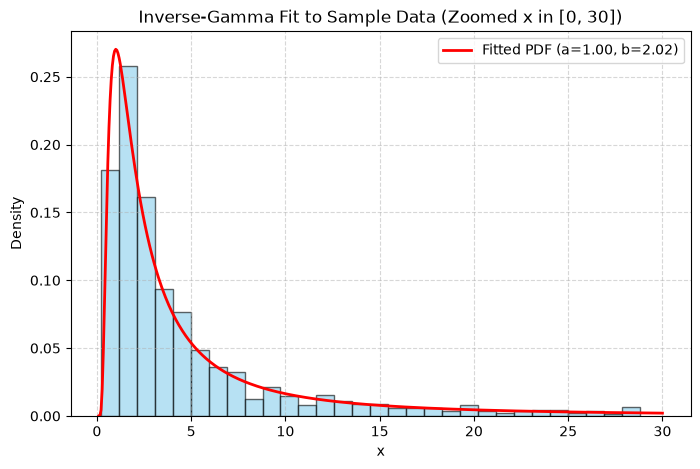

In [72]:
#plotting out of curiosity
import matplotlib.pyplot as plt
# 4. Define the Inverse-Gamma PDF formula for plotting
a_mle, b_mle = result.x
def inverse_gamma_pdf(x_vals, a, b):
    return (b**a / np.exp(gammaln(a))) * (x_vals ** (-a - 1)) * np.exp(-b / x_vals)



# Filter data to the zoomed window for a clean histogram
x_zoomed = x[x <= 30]

plt.figure(figsize=(8, 5))
plt.hist(
    x_zoomed,
    bins=30,
    density=True,
    alpha=0.6,
    color="skyblue",
    edgecolor="black",
)

# Smooth line grid for the theoretical PDF
x_grid = np.linspace(0.1, 30, 500)
pdf_grid = inverse_gamma_pdf(x_grid, a_mle, b_mle)

plt.plot(
    x_grid,
    pdf_grid,
    "r-",
    lw=2,
    label=f"Fitted PDF (a={a_mle:.2f}, b={b_mle:.2f})",
)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Inverse-Gamma Fit to Sample Data (Zoomed x in [0, 30])")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()